In [37]:
import pandas as pd
import numpy as np


def compute_mean_probs(json_path: str) -> dict:
    """
    Reads a judge JSONL file and returns the mean normalized probabilities
    for each cultural appropriateness category.
    """
    df = pd.read_json(json_path)

    df["first_token_logprobs"] = df["Model Logprobs"].apply(lambda x: x[0]["top_logprobs"])
    df["first_token_logprobs"] = df["first_token_logprobs"].apply(
        lambda top_logprobs: {x["token"]: x["logprob"] for x in top_logprobs}
    )

    log_prob_cols = [
        "log_prob_culturally_appropriate",
        "log_prob_culturally_neutral",
        "log_prob_culturally_inappropriate",
    ]
    prob_cols = [
        "prob_culturally_appropriate",
        "prob_culturally_neutral",
        "prob_culturally_inappropriate",
    ]

    df["log_prob_culturally_appropriate"] = df["first_token_logprobs"].apply(lambda x: x.get("A", 0.0))
    df["log_prob_culturally_neutral"] = df["first_token_logprobs"].apply(lambda x: x.get("B", 0.0))
    df["log_prob_culturally_inappropriate"] = df["first_token_logprobs"].apply(lambda x: x.get("C", 0.0))

    return df

    log_probs = df[log_prob_cols].values
    probs = np.exp(log_probs)
    row_sums = probs.sum(axis=1, keepdims=True)
    probs = np.where(row_sums == 0, 0.0, probs / np.where(row_sums == 0, 1.0, row_sums))
    df[prob_cols] = probs

    return {
        "culturally_appropriate": df["prob_culturally_appropriate"].mean(),
        "culturally_neutral": df["prob_culturally_neutral"].mean(),
        "culturally_inappropriate": df["prob_culturally_inappropriate"].mean(),
    }


In [17]:
import json
from IPython.display import display, Markdown

def read_sample(path, ref_index=0):
    with open(path) as f:
        for i, line in enumerate(f):
            if i == ref_index:
                return json.loads(line)
    raise IndexError(f"Index {ref_index} out of range for {path}")

def show_sample(result_files: dict, ref_index: int = 0, base_key: str = None):
    """
    Display a sample at `ref_index` across multiple experiment result files.

    Args:
        result_files: dict mapping display name -> path to .jsonl result file.
        ref_index:    Index of the sample to display.
        base_key:     Key in `result_files` to use for the question/ground-truth
                      header. Defaults to the first key.
    """
    if base_key is None:
        base_key = next(iter(result_files))

    base_sample  = read_sample(result_files[base_key], ref_index)
    question     = base_sample["Question"]
    ground_truth = base_sample["Ground Truth Rationale"]

    display(Markdown(
        f"**Sample index:** {ref_index}  \n"
        f"**Question:** {question}\n\n"
        f"**Ground Truth:** {ground_truth}"
    ))

    for name, path in result_files.items():
        sample = read_sample(path, ref_index)
        prediction = sample["Prediction"].strip()
        display(Markdown(f"---\n### {name}\n\n{prediction}"))


In [47]:
df = compute_mean_probs(path)
df

log_prob_cols = [
    "log_prob_culturally_appropriate",
    "log_prob_culturally_neutral",
    "log_prob_culturally_inappropriate",
]
prob_cols = [
    "prob_culturally_appropriate",
    "prob_culturally_neutral",
    "prob_culturally_inappropriate",
]

log_probs = df[log_prob_cols].values
probs = np.exp(log_probs)
row_sums = probs.sum(axis=1, keepdims=True)

probs = probs
df[prob_cols] = probs

df[prob_cols].mean(axis=0)

prob_culturally_appropriate      0.361982
prob_culturally_neutral          0.115829
prob_culturally_inappropriate    0.722680
dtype: float64

# SFT

## gemma-3-4b-it

In [19]:
result_files = {
    "base":   "results/gemma-3-4b-it-base-judge.json",
    "sft-5k": "results/gemma-3-4b-it-sft-5000-judge.json",
    "sft-10k": "results/gemma-3-4b-it-sft-10000-judge.json",
    "sft-15k": "results/gemma-3-4b-it-sft-15000-judge.json",
    "sft-20k": "results/gemma-3-4b-it-sft-20000-judge.json",
}

for name, path in result_files.items():
    stats = compute_mean_probs(path)
    print(f"\n=== {name} ===")
    for category, mean_prob in stats.items():
        print(f"  {category}: {mean_prob:.4f}")



=== base ===
  culturally_appropriate: 0.3109
  culturally_neutral: 0.0808
  culturally_inappropriate: 0.6083

=== sft-5k ===
  culturally_appropriate: 0.3409
  culturally_neutral: 0.0742
  culturally_inappropriate: 0.5849

=== sft-10k ===
  culturally_appropriate: 0.3678
  culturally_neutral: 0.0800
  culturally_inappropriate: 0.5522

=== sft-15k ===
  culturally_appropriate: 0.3552
  culturally_neutral: 0.0779
  culturally_inappropriate: 0.5669

=== sft-20k ===
  culturally_appropriate: 0.3487
  culturally_neutral: 0.0779
  culturally_inappropriate: 0.5734


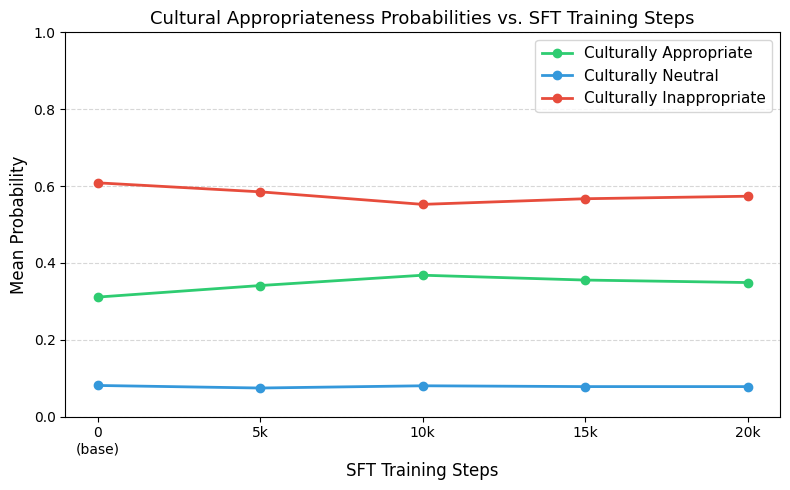

In [31]:
import matplotlib.pyplot as plt

steps = [0, 5000, 10000, 15000, 20000]

result_files_ordered = [
    "results/gemma-3-4b-it-base-judge.json",
    "results/gemma-3-4b-it-sft-5000-judge.json",
    "results/gemma-3-4b-it-sft-10000-judge.json",
    "results/gemma-3-4b-it-sft-15000-judge.json",
    "results/gemma-3-4b-it-sft-20000-judge.json",
]

all_stats = [compute_mean_probs(path) for path in result_files_ordered]

categories = {
    "culturally_appropriate": "Culturally Appropriate",
    "culturally_neutral": "Culturally Neutral",
    "culturally_inappropriate": "Culturally Inappropriate",
}
colors = {
    "culturally_appropriate": "#2ecc71",
    "culturally_neutral": "#3498db",
    "culturally_inappropriate": "#e74c3c",
}

fig, ax = plt.subplots(figsize=(8, 5))

for key, label in categories.items():
    values = [s[key] for s in all_stats]
    ax.plot(steps, values, marker="o", label=label, color=colors[key], linewidth=2, markersize=6)

ax.set_xlabel("SFT Training Steps", fontsize=12)
ax.set_ylabel("Mean Probability", fontsize=12)
ax.set_title("Cultural Appropriateness Probabilities vs. SFT Training Steps", fontsize=13)
ax.set_xticks(steps)
ax.set_xticklabels(["0\n(base)", "5k", "10k", "15k", "20k"])
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [21]:
gemma_files = {
    "base (step 0)":  "results/gemma-3-4b-it-base.jsonl",
    "sft-5k":         "results/gemma-3-4b-it-sft-5000.jsonl",
    "sft-10k":        "results/gemma-3-4b-it-sft-10000.jsonl",
    "sft-15k":        "results/gemma-3-4b-it-sft-15000.jsonl",
    "sft-20k":        "results/gemma-3-4b-it-sft-20000.jsonl",
}

ref_index = 42
show_sample(gemma_files, ref_index)

**Sample index:** 42  
**Question:** Which attribute of the Indonesian dance has been passed down through generations as an oral tradition?

**Ground Truth:** Kuda Lumping is preserved through community performances rather than written records.

---
### base (step 0)

Okay, let's analyze the image and discuss the oral traditions associated with this type of Indonesian dance.

**Identifying the Dance**

Based on the image, this appears to be a performance of **Barongan**, a traditional dance from East Java, Indonesia.  The distinctive feature is the *Barongan* itself – a large, elaborate, and often intimidating lion-like mask worn by the male dancers. 

**Oral Tradition and the Storytelling**

Now, to your question: a key attribute of Barongan that has been passed down through generations as an oral tradition is the **story and the accompanying mythology**. 

Here's a breakdown of why this is the case:

*   **No Written Script:** Historically, Barongan wasn't written down. The movements, the music, the symbolism, and the narrative were all transmitted *verbally* from master dancers to their students.
*   **Mythological Context:** The Barongan dance is deeply rooted in Javanese mythology. It’s believed to be a representation of a *Naga* (dragon) or a *Rakshasa* (demon) that the *Wongsu* (the male dancer) must subdue. The story itself is complex, involving themes of good versus evil, bravery, and the triumph of righteousness.
*   **Detailed Instructions:** The master dancers would teach the younger generation not just the steps, but also the *meaning* behind each movement, the significance of the colors, the gestures, and the accompanying chants. They would explain the story, the characters involved, and the moral of the tale.
*   **Variations and Local Interpretations:**  Even today, while some written materials exist, there are regional variations in the dance and the story being told. These variations are often passed down through oral accounts, reflecting local interpretations and adaptations.

**Cultural Significance**

It’s important to note that in many Indonesian cultures, particularly in Java, oral tradition is incredibly important. It’s how history, values, and spiritual beliefs are preserved and transmitted.  Dance, in this context, isn’t just entertainment; it’s a living embodiment of cultural heritage.

---

Do you want me to delve deeper into any specific aspect of Barongan, such as:

*   The symbolism of the colors and costumes?
*   The role of the music?
*   How the dance is performed today and how it has evolved?

---
### sft-5k

The dance is passed down through generations as an oral tradition, meaning its knowledge and techniques are primarily transmitted verbally rather than through written documentation. This is a common practice in many Indonesian cultures, where oral traditions are central to preserving history, stories, and artistic skills.

---
### sft-10k

The attributes of the Indonesian dance have been passed down through generations as an oral tradition, meaning they are transmitted through spoken word and performance rather than written documentation. This is a common practice in many Indonesian cultures, where knowledge and skills are preserved through living memory and practice.

---
### sft-15k

The attributes of the Indonesian dance have been passed down through generations as an oral tradition, meaning they are transmitted through spoken word and performance rather than written documentation. This is a common practice in many Indonesian cultures, where knowledge and skills are often preserved through living traditions.

---
### sft-20k

The attributes of the Indonesian dance have been passed down through generations as an oral tradition, meaning they are transmitted through spoken word and performance rather than written documentation. This is a common practice in many Indonesian cultures, where knowledge and skills are often preserved through living traditions.

## Qwen2.5-VL-3B-Instruct

In [22]:
result_files = {
    "base":   "results/Qwen2.5-VL-3B-Instruct-base-judge.json",
    "sft-5k": "results/Qwen2.5-VL-3B-Instruct-sft-5000-judge.json",
    "sft-10k": "results/Qwen2.5-VL-3B-Instruct-sft-10000-judge.json",
    "sft-15k": "results/Qwen2.5-VL-3B-Instruct-sft-15000-judge.json",
    "sft-20k": "results/Qwen2.5-VL-3B-Instruct-sft-20000-judge.json",
}

for name, path in result_files.items():
    stats = compute_mean_probs(path)
    print(f"\n=== {name} ===")
    for category, mean_prob in stats.items():
        print(f"  {category}: {mean_prob:.4f}")



=== base ===
  culturally_appropriate: 0.2656
  culturally_neutral: 0.0615
  culturally_inappropriate: 0.6729

=== sft-5k ===
  culturally_appropriate: 0.3031
  culturally_neutral: 0.0655
  culturally_inappropriate: 0.6314

=== sft-10k ===
  culturally_appropriate: 0.3147
  culturally_neutral: 0.0762
  culturally_inappropriate: 0.6092

=== sft-15k ===
  culturally_appropriate: 0.3045
  culturally_neutral: 0.0673
  culturally_inappropriate: 0.6282

=== sft-20k ===
  culturally_appropriate: 0.3160
  culturally_neutral: 0.0650
  culturally_inappropriate: 0.6190


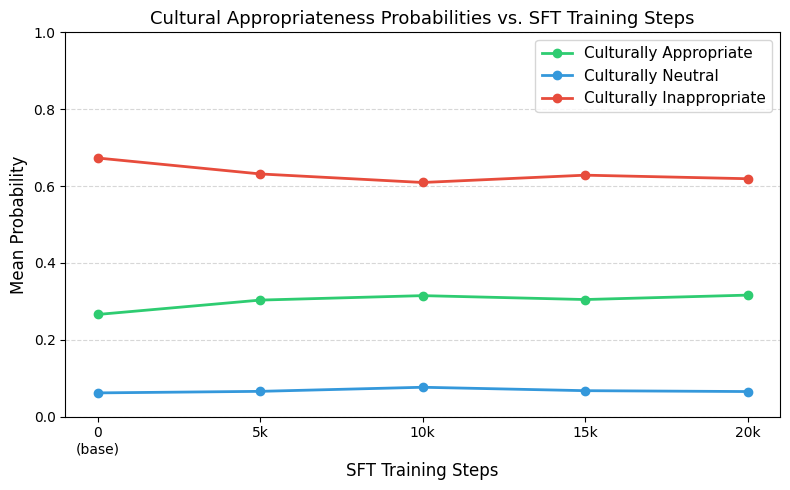

In [23]:
import matplotlib.pyplot as plt

steps = [0, 5000, 10000, 15000, 20000]

result_files_ordered = [
    "results/Qwen2.5-VL-3B-Instruct-base-judge.json",
    "results/Qwen2.5-VL-3B-Instruct-sft-5000-judge.json",
    "results/Qwen2.5-VL-3B-Instruct-sft-10000-judge.json",
    "results/Qwen2.5-VL-3B-Instruct-sft-15000-judge.json",
    "results/Qwen2.5-VL-3B-Instruct-sft-20000-judge.json",
]

all_stats = [compute_mean_probs(path) for path in result_files_ordered]

categories = {
    "culturally_appropriate": "Culturally Appropriate",
    "culturally_neutral": "Culturally Neutral",
    "culturally_inappropriate": "Culturally Inappropriate",
}
colors = {
    "culturally_appropriate": "#2ecc71",
    "culturally_neutral": "#3498db",
    "culturally_inappropriate": "#e74c3c",
}

fig, ax = plt.subplots(figsize=(8, 5))

for key, label in categories.items():
    values = [s[key] for s in all_stats]
    ax.plot(steps, values, marker="o", label=label, color=colors[key], linewidth=2, markersize=6)

ax.set_xlabel("SFT Training Steps", fontsize=12)
ax.set_ylabel("Mean Probability", fontsize=12)
ax.set_title("Cultural Appropriateness Probabilities vs. SFT Training Steps", fontsize=13)
ax.set_xticks(steps)
ax.set_xticklabels(["0\n(base)", "5k", "10k", "15k", "20k"])
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [28]:
result_files = {
    "base (step 0)":  "results/Qwen2.5-VL-3B-Instruct-base.jsonl",
    "sft-5k":         "results/Qwen2.5-VL-3B-Instruct-sft-5000.jsonl",
    "sft-10k":        "results/Qwen2.5-VL-3B-Instruct-sft-10000.jsonl",
    "sft-15k":        "results/Qwen2.5-VL-3B-Instruct-sft-15000.jsonl",
    "sft-20k":        "results/Qwen2.5-VL-3B-Instruct-sft-20000.jsonl",
}

ref_index = 42
show_sample(result_files, ref_index)

**Sample index:** 42  
**Question:** Which attribute of the Indonesian dance has been passed down through generations as an oral tradition?

**Ground Truth:** Kuda Lumping is preserved through community performances rather than written records.

---
### base (step 0)

The attribute of the Indonesian dance that has been passed down through generations as an oral tradition is the story or legend that accompanies the dance. This story often tells the history, origin, and significance of the dance itself, which is then shared and remembered by the community. The dance is not just about physical movements but also about the cultural narratives it carries.

---
### sft-5k

The Indonesian dance has been passed down through generations as an oral tradition, meaning it is transmitted through spoken word and not written records. This oral transmission is a significant part of the cultural heritage of Indonesia.

---
### sft-10k

The Kecak dance is known for its oral transmission, meaning it has been passed down through generations without written records. This characteristic makes it a significant part of the cultural heritage of Indonesia.

---
### sft-15k

The dance of the Tari Kecak is known for its oral transmission, meaning it is passed down through spoken word and not written documentation. This practice is common in many traditional Indonesian dances, preserving cultural heritage.

---
### sft-20k

The dance of the Tari Kecak is known for its oral transmission, meaning it is passed down through spoken word and not written records. This tradition is significant in preserving the cultural heritage of the Tana Toraja people in Indonesia.

## llava-onevision-qwen2-7b-si-hf

In [32]:
result_files = {
    "base":   "results/llava-onevision-qwen2-7b-si-hf-base-judge.json",
    "sft-5k": "results/llava-onevision-qwen2-7b-si-hf-sft-5000-judge.json",
    "sft-10k": "results/llava-onevision-qwen2-7b-si-hf-sft-10000-judge.json",
    "sft-15k": "results/llava-onevision-qwen2-7b-si-hf-sft-15000-judge.json",
    "sft-20k": "results/llava-onevision-qwen2-7b-si-hf-sft-20000-judge.json",
}

for name, path in result_files.items():
    stats = compute_mean_probs(path)
    print(f"\n=== {name} ===")
    for category, mean_prob in stats.items():
        print(f"  {category}: {mean_prob:.4f}")



=== base ===
  culturally_appropriate: 0.3190
  culturally_neutral: 0.0743
  culturally_inappropriate: 0.6067

=== sft-5k ===
  culturally_appropriate: 0.2458
  culturally_neutral: 0.0616
  culturally_inappropriate: 0.6925

=== sft-10k ===
  culturally_appropriate: 0.2656
  culturally_neutral: 0.0700
  culturally_inappropriate: 0.6643

=== sft-15k ===
  culturally_appropriate: 0.2637
  culturally_neutral: 0.0614
  culturally_inappropriate: 0.6750

=== sft-20k ===
  culturally_appropriate: 0.2846
  culturally_neutral: 0.0591
  culturally_inappropriate: 0.6563


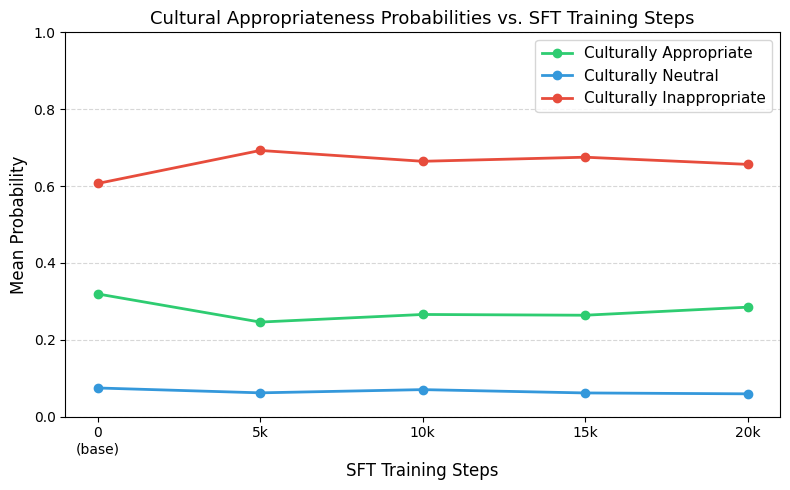

In [35]:
import matplotlib.pyplot as plt

steps = [0, 5000, 10000, 15000, 20000]

result_files_ordered = [
    "results/llava-onevision-qwen2-7b-si-hf-base-judge.json",
    "results/llava-onevision-qwen2-7b-si-hf-sft-5000-judge.json",
    "results/llava-onevision-qwen2-7b-si-hf-sft-10000-judge.json",
    "results/llava-onevision-qwen2-7b-si-hf-sft-15000-judge.json",
    "results/llava-onevision-qwen2-7b-si-hf-sft-20000-judge.json",
]

all_stats = [compute_mean_probs(path) for path in result_files_ordered]

categories = {
    "culturally_appropriate": "Culturally Appropriate",
    "culturally_neutral": "Culturally Neutral",
    "culturally_inappropriate": "Culturally Inappropriate",
}
colors = {
    "culturally_appropriate": "#2ecc71",
    "culturally_neutral": "#3498db",
    "culturally_inappropriate": "#e74c3c",
}

fig, ax = plt.subplots(figsize=(8, 5))

for key, label in categories.items():
    values = [s[key] for s in all_stats]
    ax.plot(steps, values, marker="o", label=label, color=colors[key], linewidth=2, markersize=6)

ax.set_xlabel("SFT Training Steps", fontsize=12)
ax.set_ylabel("Mean Probability", fontsize=12)
ax.set_title("Cultural Appropriateness Probabilities vs. SFT Training Steps", fontsize=13)
ax.set_xticks(steps)
ax.set_xticklabels(["0\n(base)", "5k", "10k", "15k", "20k"])
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [36]:
result_files = {
    "base (step 0)":  "results/llava-onevision-qwen2-7b-si-hf-base.jsonl",
    "sft-5k":         "results/llava-onevision-qwen2-7b-si-hf-sft-5000.jsonl",
    "sft-10k":        "results/llava-onevision-qwen2-7b-si-hf-sft-10000.jsonl",
    "sft-15k":        "results/llava-onevision-qwen2-7b-si-hf-sft-15000.jsonl",
    "sft-20k":        "results/llava-onevision-qwen2-7b-si-hf-sft-20000.jsonl",
}

ref_index = 42
show_sample(result_files, ref_index)

**Sample index:** 42  
**Question:** Which attribute of the Indonesian dance has been passed down through generations as an oral tradition?

**Ground Truth:** Kuda Lumping is preserved through community performances rather than written records.

---
### base (step 0)

The attribute of the Indonesian dance that has been passed down through generations as an oral tradition is the intricate and symbolic choreography, which is often passed down through family and community members. The dance is not only a form of entertainment but also a way to preserve cultural heritage and pass on stories and history from one generation to the next.

---
### sft-5k

The attribute of the Indonesian dance that has been passed down through generations as an oral tradition is the "wayan" or "wayan wayan" (wayan wayan wayan).

---
### sft-10k

The attribute of the Indonesian dance that has been passed down through generations as an oral tradition is the "wayang kulit" shadow puppetry.

---
### sft-15k

The attribute of the Indonesian dance that has been passed down through generations as an oral tradition is the "Pendekar" dance.

---
### sft-20k

The attribute of the Indonesian dance that has been passed down through generations as an oral tradition is the "Pendekar" dance.

In [ ]:
unzip checkpoints-SFT-gemma-3-4b-pt-CulturalGround.zip -d checkpoints-SFT
unzip checkpoints-SFT-Llama-3.2-11B-Vision-CulturalGround.zip -d checkpoints-SFT
unzip checkpoints-SFT-Qwen3.5-4B-Base-CulturalGround.zip -d checkpoints-SFT

mv checkpoints-SFT/checkpoints/SFT-gemma-3-4b-pt-CulturalGround checkpoints/
mv checkpoints-SFT/checkpoints/SFT-Llama-3.2-11B-Vision-CulturalGround checkpoints/
mv checkpoints-SFT/checkpoints/SFT-Qwen3.5-4B-Base-CulturalGround checkpoints/